In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [ ]:
model= ChatGroq(
    model='llama-3.3-70b-versatile',
    temperature=0.7,
    max_tokens=2000
)

In [16]:
class BlogState(TypedDict):
    topic:str
    outline:str
    content:str
    evaluate:int

In [8]:
def gen_outline(state: BlogState) -> BlogState:
    topic= state['topic']
    prompt=f'Generate the outline of the given {topic}'
    outline= model.invoke(prompt).content
    state['outline']=outline
    return state

In [9]:
def gen_blog(state: BlogState)-> BlogState:
    topic=state['topic']
    outline=state['outline']
    prompt=f'Generate a blog from the given {topic} and given outline /n {outline}. '
    content= model.invoke(prompt).content
    state['content']=content
    return state

In [17]:
def evaluate_blog(state: BlogState)-> BlogState:
    topic=state['topic']
    outline=state['outline']
    content=state['content']
    prompt=f'Based on the {topic} and {outline} evaluate the {content} of my blog with a score of 1 to 100, where 1 means very bad and 100 means exactly the same. My output should be only an integer, no words.'
    evaluate= model.invoke(prompt).content
    state['evaluate']=evaluate
    return state

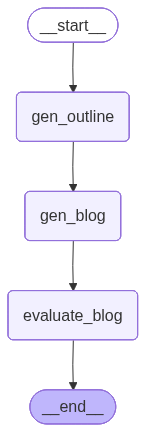

In [18]:
graph = StateGraph(BlogState)

graph.add_node('gen_outline',gen_outline)
graph.add_node('gen_blog',gen_blog)
graph.add_node('evaluate_blog',evaluate_blog)

graph.add_edge(START,'gen_outline')
graph.add_edge('gen_outline','gen_blog')
graph.add_edge('gen_blog','evaluate_blog')
graph.add_edge('evaluate_blog',END)

workflow= graph.compile()
workflow

In [20]:
initial_state={'topic':'CyberFraud'}
out_state=workflow.invoke(initial_state)
out_state

{'topic': 'CyberFraud',
 'outline': "To provide a comprehensive outline of cyberfraud, I'll break it down into key areas. Please note that the specifics can vary widely depending on the nature and scope of the fraud. Here's a general outline:\n\n### I. Introduction to Cyberfraud\n- **Definition**: Cyberfraud refers to any type of fraudulent activity that occurs over the internet.\n- **Importance**: Understanding cyberfraud is crucial for protecting personal and organizational assets in the digital age.\n\n### II. Types of Cyberfraud\n1. **Phishing**: Attempting to obtain sensitive information by disguising as a trustworthy entity.\n2. **Identity Theft**: Stealing personal information to impersonate someone else, often for financial gain.\n3. **Online Scams**: Various schemes to deceive and cheat people out of their money or valuable information.\n4. **Ransomware**: Malware that demands payment in exchange for restoring access to data.\n5. **Credit/Debit Card Fraud**: Unauthorized use o